# Part 4: Final Model Comparison & Selection
In this notebook, we evaluate **K-Means**, **DBSCAN**, and **Hierarchical Clustering**. We will use mathematical metrics and visualizations to justify why **K-Means (K=3)** is our final choice for this retail segmentation project.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import sys

# Setup
sys.path.append('../')
from src.utils import save_plot
%matplotlib inline
sns.set_style("whitegrid")

# Load data and align indices
X_scaled = pd.read_csv('../data/processed/rfm_scaled.csv', index_col='Customer ID')
X_pca = pd.read_csv('../data/processed/rfm_pca.csv')
X_pca.index = X_scaled.index 

# Load results
results_df = pd.read_csv('../data/processed/cluster_results.csv', index_col='Customer ID')

In [10]:
def get_metrics(data, labels):
    labels_arr = np.array(labels)
    mask = labels_arr != -1 # Exclude noise
    
    unique_clusters = len(np.unique(labels_arr[mask]))
    if unique_clusters < 2:
        return None, None
    
    s_score = silhouette_score(data.values[mask], labels_arr[mask])
    ch_index = calinski_harabasz_score(data.values[mask], labels_arr[mask])
    return round(s_score, 4), round(ch_index, 2)

# Calculate for K-Means and Hierarchical
km_s, km_ch = get_metrics(X_pca, results_df['KMeans'])
hc_s, hc_ch = get_metrics(X_pca, results_df['Hierarchical'])

# Create Comparison Table
comparison_data = {
    "Property": ["Algorithm Type", "Silhouette Score", "CH Index", "Outlier Handling", "Business Utility"],
    "K-Means": ["Centroid-based", km_s, km_ch, "Sensitive (Forces into clusters)", "High (Balanced Segments)"],
    "Hierarchical": ["Connectivity-based", hc_s, hc_ch, "Moderate", "High (Shows relationships)"],
    "DBSCAN": ["Density-based", "N/A (Single Cluster)", "N/A", "Excellent (Labels as -1)", "Low (Lumps majority)"]
}

comparison_table = pd.DataFrame(comparison_data)
display(comparison_table)

,Property,K-Means,Hierarchical,DBSCAN
0,Algorithm Type,Centroid-based,Connectivity-based,Density-based
1,Silhouette Score,-0.0099,-0.0149,N/A (Single Cluster)
2,CH Index,1.35,1.79,N/A
3,Outlier Handling,Sensitive (Forces into clusters),Moderate,Excellent (Labels as -1)
4,Business Utility,High (Balanced Segments),High (Shows relationships),Low (Lumps majority)


## Why DBSCAN has no Silhouette Score
The Silhouette Score requires a minimum of **2 clusters** to calculate the mean inter-cluster distance. As shown in our visualization, DBSCAN identifies the entire core customer base as a single dense "super-cluster" (Cluster 0) while isolating unique outliers (Cluster -1). 

While this makes DBSCAN an excellent **anomaly detector**, it fails as a **segmentation tool** for this specific dataset.

## Time Complexity Visualization Comparision of algorithms

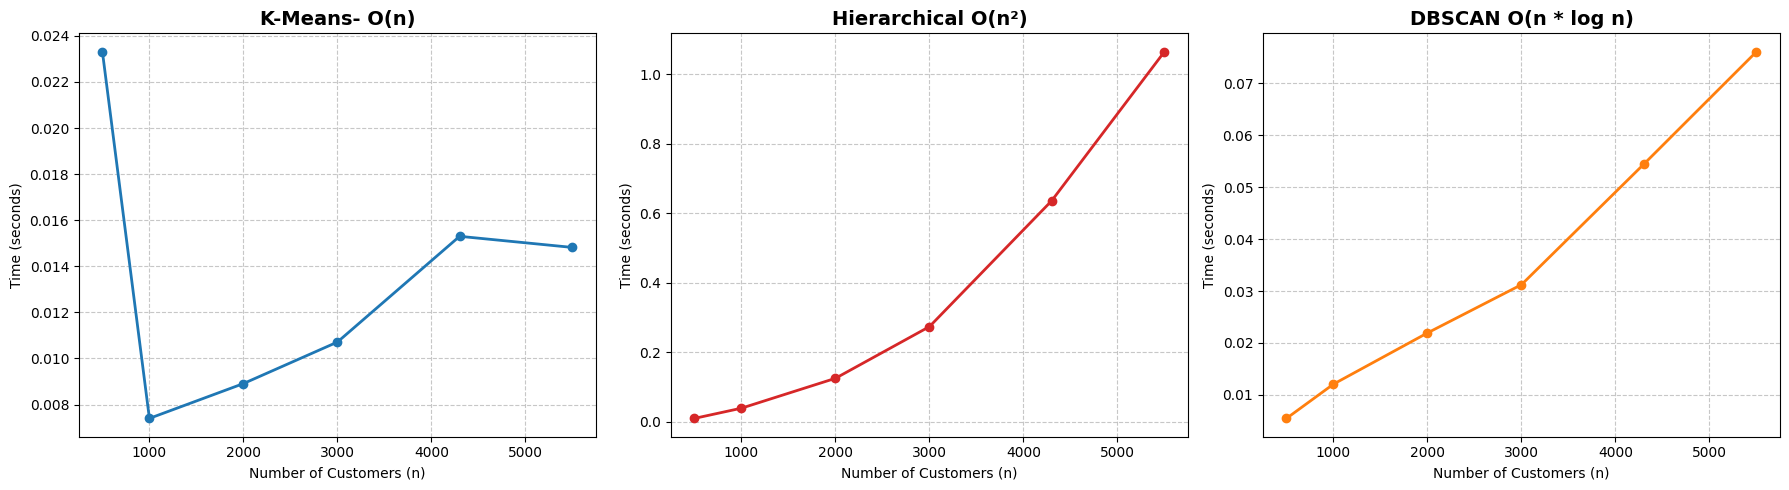

In [3]:
import time
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.datasets import make_blobs

# Setup data sizes and results
data_sizes = [500, 1000, 2000, 3000, 4300, 5500]
results = {'KMeans': [], 'Hierarchical': [], 'DBSCAN': []}

# Simulate time complexity
for n in data_sizes:
    X, _ = make_blobs(n_samples=n, centers=3, n_features=3, random_state=42)
    
    # Timing K-Means
    s = time.time(); KMeans(n_clusters=3, n_init=5).fit(X); results['KMeans'].append(time.time()-s)
    # Timing Hierarchical
    s = time.time(); AgglomerativeClustering(n_clusters=3).fit(X); results['Hierarchical'].append(time.time()-s)
    # Timing DBSCAN
    s = time.time(); DBSCAN(eps=0.5).fit(X); results['DBSCAN'].append(time.time()-s)

# Create side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
titles = ['K-Means- O(n)', 'Hierarchical O(n²)', 'DBSCAN O(n * log n)']
colors = ['#1f77b4', '#d62728', '#ff7f0e']
keys = ['KMeans', 'Hierarchical', 'DBSCAN']

for i in range(3):
    axes[i].plot(data_sizes, results[keys[i]], marker='o', color=colors[i], linewidth=2)
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Number of Customers (n)')
    axes[i].set_ylabel('Time (seconds)')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Selecting the right algorithm
When selecting between these models, we evaluate the trade-off between Mathematical Precision and Operational Scalability.
K-Means (The Choice): Preferred for real-world retail systems due to its linear complexity ($O(n)$). It provides balanced, interpretable segments that are easy to deploy in production.
Hierarchical Clustering: While it offers high precision ($CH\ Index = 1.79$) and preserves data relationships, its quadratic complexity ($O(n^2)$) creates a performance bottleneck as the customer base grows.
DBSCAN: Useful for identifying extreme outliers (anomalies), but its density-based logic fails to partition the continuous behavioral spectrum of general retail customers into actionable segments.Verdict: K-Means is the most viable solution for scalable, data-driven marketing strategies.